In [1]:
import pandas as pd #use for manipulation(1d arrays & 2D arrays) & Data reshaping

In [19]:
df=pd.read_csv('/content/drive/MyDrive/Weather Production/weather_classification_data.csv')

In [20]:
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [21]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [23]:
#print column

Temperature = df['Temperature']
Humidity = df['Humidity']

print("Temperature")
print(Temperature)

print("Humidity")
print(Humidity)

Temperature
0        14.0
1        39.0
2        30.0
3        38.0
4        27.0
         ... 
13195    10.0
13196    -1.0
13197    30.0
13198     3.0
13199    -5.0
Name: Temperature, Length: 13200, dtype: float64
Humidity
0        73
1        96
2        64
3        83
4        74
         ..
13195    74
13196    76
13197    77
13198    76
13199    38
Name: Humidity, Length: 13200, dtype: int64


In [24]:
#Row Selection

first_row = df.iloc[0]   #by index
rows_0_2 = df.iloc[0:3]   #slice rows

print("\nFirst Row:")
print(first_row)

print("\nRow 0 to 2:")
print(rows_0_2)



First Row:
Temperature                      14.0
Humidity                           73
Wind Speed                        9.5
Precipitation (%)                82.0
Cloud Cover             partly cloudy
Atmospheric Pressure          1010.82
UV Index                            2
Season                         Winter
Visibility (km)                   3.5
Location                       inland
Weather Type                    Rainy
Name: 0, dtype: object

Row 0 to 2:
   Temperature  Humidity  Wind Speed  Precipitation (%)    Cloud Cover  \
0         14.0        73         9.5               82.0  partly cloudy   
1         39.0        96         8.5               71.0  partly cloudy   
2         30.0        64         7.0               16.0          clear   

   Atmospheric Pressure  UV Index  Season  Visibility (km)  Location  \
0               1010.82         2  Winter              3.5    inland   
1               1011.43         7  Spring             10.0    inland   
2               1018.

In [25]:
#Handle missing Values
#check missing values

print(df.isnull().sum())

#fill missing values
# df['chol'].fillna(df['chol'].mean(), inplace=True)

#Drop rows with missing values
# df.dropna(inplace=True)


Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64


In [26]:
print("Mean of Temp :")
print(df['Temperature'].mean())
print("Max of Temp :")
print(df['Temperature'].max())
print("Min of Temp :")
print(df['Temperature'].min())
print("Seasonal Values :")
print(df['Season'].value_counts())

Mean of Temp :
19.12757575757576
Max of Temp :
109.0
Min of Temp :
-25.0
Seasonal Values :
Season
Winter    5610
Spring    2598
Autumn    2500
Summer    2492
Name: count, dtype: int64


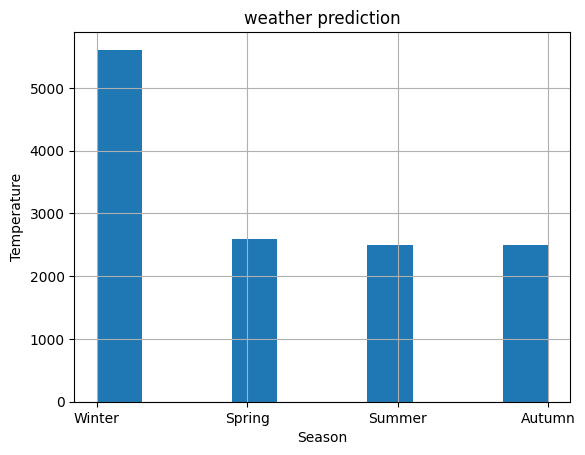

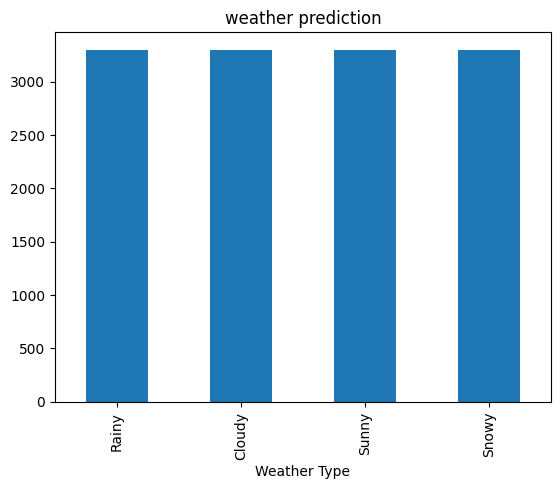

In [28]:
#Visulization with Panadas (data representations through graphs)
import matplotlib.pyplot as plt

#Histogram of Season
df['Season'].hist(bins=10)
plt.title('weather prediction')
plt.xlabel('Season')
plt.ylabel('Temperature')
plt.show()

#Bar plot of target counts
df['Weather Type'].value_counts().plot(kind='bar')
plt.title('weather prediction')
plt.show()

In [35]:
from sklearn.preprocessing import LabelEncoder  #string value to dicrete value

#Initialize LabelEncoder
le = LabelEncoder()

#apply label encoding to the 'Weather Type' column only
# df['Weather Type'] = le.fit_transform(df['Weather Type'])

df['Location'] = le.fit_transform(df['Location'])

#print the encoded 'name' column
print(df['Location'])



0        1
1        1
2        2
3        0
4        2
        ..
13195    2
13196    0
13197    0
13198    1
13199    2
Name: Location, Length: 13200, dtype: int64


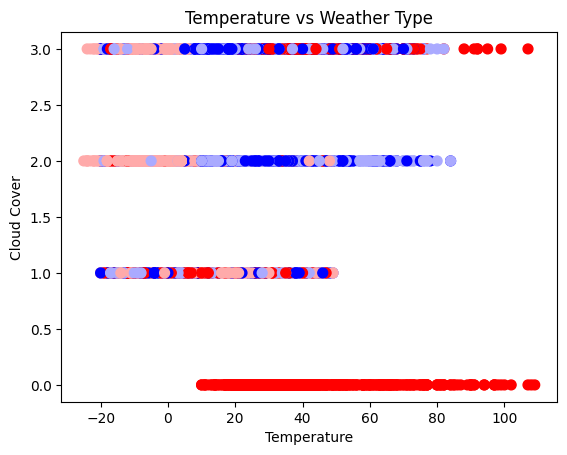

In [36]:
#Scatter Plot

plt.scatter(df['Temperature'], df['Cloud Cover'], c=df['Weather Type'], cmap='bwr', s=50)
plt.title('Temperature vs Weather Type')
plt.xlabel('Temperature')
plt.ylabel('Cloud Cover')
plt.show()

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

#prepare feature and targert
#Features (all columns expect Weather Type)
X = df.drop('Weather Type', axis=1)

#Weather Type
y = df['Weather Type']

#split dataset into trainig and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training Samples:', X_train.shape[0])
print('Testing Samples:', X_test.shape[0])

Training Samples: 10560
Testing Samples: 2640


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  int64  
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  int64  
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  int64  
 10  Weather Type          13200 non-null  int64  
dtypes: float64(5), int64(6)
memory usage: 1.1 MB


In [40]:
#feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#print the first 5 rows of the scaled training data
print("Scaled X_train (first 5 rows):\n", X_train_scaled[:5])

#print the first 5 rows of ths scaled testing data
print("\nScaled X_test (first 5 rows):\n", X_test_scaled[:5])

Scaled X_train (first 5 rows):
 [[ 0.72798445 -0.129706   -0.5536792   1.20474657  0.99473094  0.12312287
  -0.52309687 -0.72244736 -1.17954402 -0.11088224]
 [-0.2483393   1.35248791  0.17067625  0.10905348  0.01053168  0.30482752
  -1.04194372 -1.57906584 -0.4360718   1.14952303]
 [ 0.49826122 -0.52495771 -0.48124366 -1.3310003  -1.95786685  0.53001245
   1.55229052  0.13417111  1.05087263 -0.11088224]
 [ 1.58944659  0.75961034  5.02385783  0.98560795  0.01053168 -0.35864942
  -0.52309687  0.99078959 -1.03084958 -1.37128752]
 [-0.07604688 -0.129706    0.60528953 -1.36230581  0.99473094 -0.14983669
  -0.78252029 -1.57906584  0.75348375 -1.37128752]]

Scaled X_test (first 5 rows):
 [[ 0.21110717 -1.51308699 -0.77098584 -1.48752788 -1.95786685  0.41782258
   1.29286709 -1.57906584  1.34826152 -0.11088224]
 [ 2.45090872  1.25367498  0.67772508  0.92299692 -1.95786685  0.53538039
   1.55229052  0.13417111 -0.4360718  -0.11088224]
 [ 1.18743092 -0.87080296 -1.13316357 -1.29969478  0.9947309

In [42]:
#Train logistic regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

#Make prediction
y_pred = model.predict(X_test_scaled)

#Evalute the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.8484848484848485
Confusion Matrix:
 [[529  58  18  46]
 [ 36 539  46  26]
 [ 23   4 659  15]
 [ 71  41  16 513]]


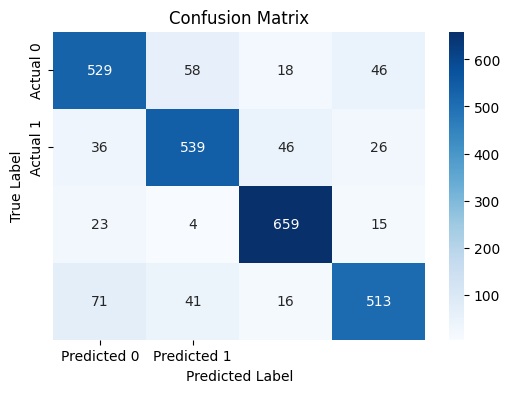

In [43]:
import seaborn as sns

#plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
xticklabels = ['Predicted 0', 'Predicted 1'],
yticklabels = ['Actual 0', 'Actual 1'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()